In [1]:
from alldata import PresentationMapper, DataAggregator
from gaze import GazeData

In [2]:
import pandas as pd
df_pos = pd.read_csv("data/sentence_position.csv") # with pilot 2 index
df_pos.head() 

,presentation_index,part_nr,line_idx,text,top,bottom,left,right
0,0,1,0,Eva planifie un city-trip à San Francisco.,412,500,414,1506
1,0,2,0,Elle voudrait trouver un vol pas cher.,580,668,466,1454
2,1,1,0,Jeanne fait des activités touristiques.,412,500,453,1467
3,1,2,0,Elle prend beaucoup de selfies.,580,668,557,1363
4,2,1,0,Elena est de sortie en ville lorsque sa mère l...,236,324,115,1805


In [3]:
mapper2 = PresentationMapper("data/sentences.js", "data/pilot_2/sentence_order_gaze_2.csv")

gaze1 = GazeData("data/pilot_1/pilot1_gaze_2026-06-22_17-40-03 (1).csv")
gaze2 = GazeData("data/pilot_2/gaze_2.csv")
gaze3 = GazeData("data/pilot_3/gaze_2026-06-24_18-05-11.csv")

order1 = "data/pilot_1/pilot1_sentence_order_gaze_2026-06-22_17-40-03 (1).csv"
order2 = "data/pilot_2/sentence_order_gaze_2.csv"
order3 = "data/pilot_3/sentence_order_gaze_2026-06-24_18-05-11.csv"


[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/pilot_2/sentence_order_gaze_2.csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, il décide de regarder l'heure sur son portable."
  exp_order shape : (97, 2)
  exp_order columns : ['first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                                                                                                                                                                             first  real_index
                  0                                                                                                                                                                        Eva planifie un city-trip à San Francisco.          66

In [4]:
aggregator = DataAggregator(
    gazedata=[gaze1, gaze2, gaze3],
    real_order_path="data/sentences.js",
    exp_order_paths=[order1, order2, order3],
    df_pos=df_pos,
    df_pos_participant_idx=1,  # df_pos was built from participant 2 (0-indexed = 1)
    sentence_metadata_path="data/combined_valid_sentences.xlsx"
)

# Per participant stats with real_index
df_all = aggregator.compute_gaze_fix_stats()

# Aggregated across participants
df_aggregated = aggregator.aggregate_by_sentence()


[DataAggregator] Initialising...
  Number of participants : 3
  df_pos shape           : (331, 8)
  df_pos built from participant (0-indexed): 1
[nan]
Length: 1, dtype: str
[load_sentence_metadata] Loaded 97 sentences
  groupUnc values : <StringArray>
['high', 'low', 'none']
Length: 3, dtype: str
  groupRes values : <StringArray>
['low', 'high', nan]
Length: 3, dtype: str
  groupVal values : <StringArray>
['neg', 'pos']
Length: 2, dtype: str

[DataAggregator] Building mappers...

[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/pilot_1/pilot1_sentence_order_gaze_2026-06-22_17-40-03 (1).csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, il décide de regarder l'heure sur son portable."
  exp_order shape : (97, 2)
  exp_order columns : ['first', 'second']
  

In [5]:
df_aggregated.head()

,real_index,mean_gaze_samples,std_gaze_samples,mean_fixations,std_fixations,n_participants,groupUnc,groupRes,groupVal
0,0,3.333333,5.773503,0.333333,0.577350,3,high,low,neg
1,1,46.333333,77.668097,0.666667,1.154701,3,high,high,neg
2,2,7.333333,7.023769,0.000000,0.000000,3,low,high,pos
3,3,63.666667,105.120566,0.000000,0.000000,3,high,low,pos
4,4,79.666667,137.986714,0.000000,0.000000,3,low,low,pos


In [6]:
# Get data for participant 0
df_p1 = df_all[df_all["participant"] == 0]

# Get data for participant 1
df_p2 = df_all[df_all["participant"] == 1]

# plots !

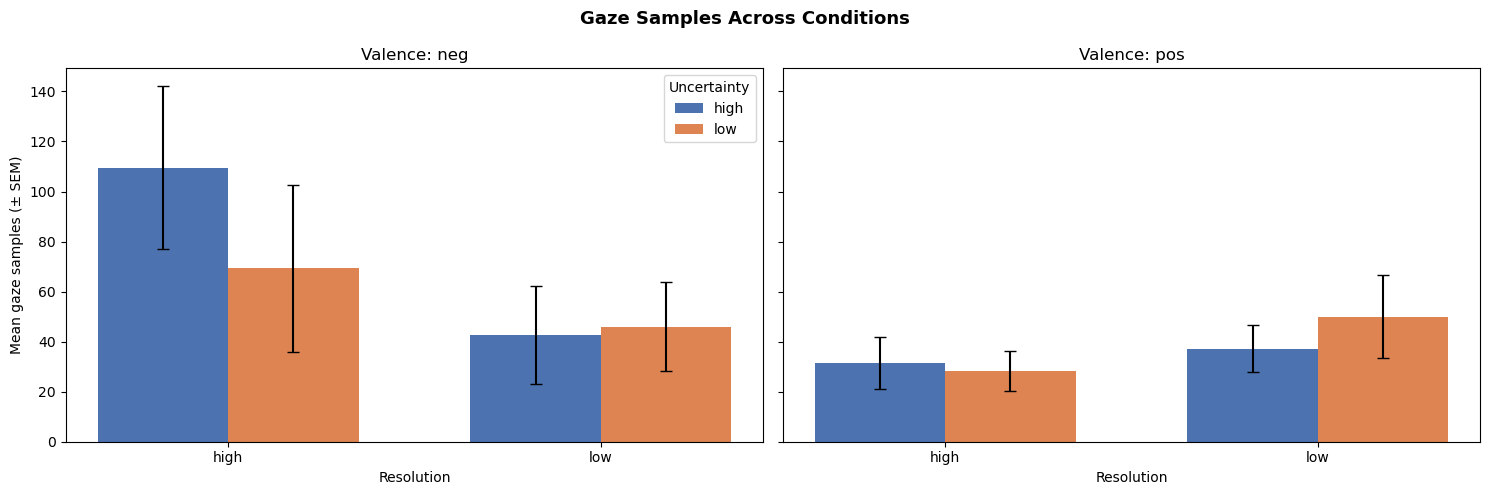

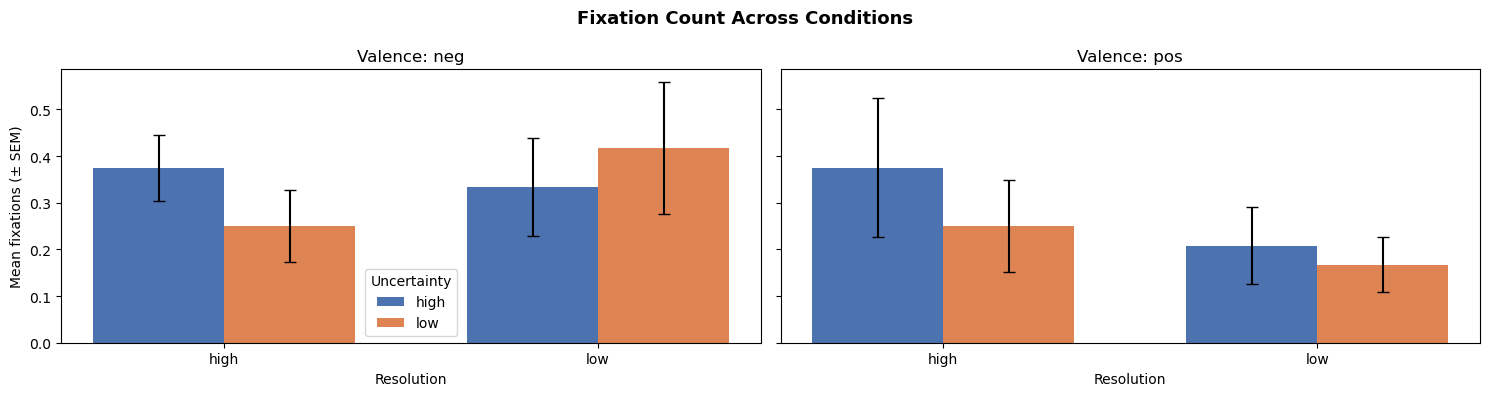

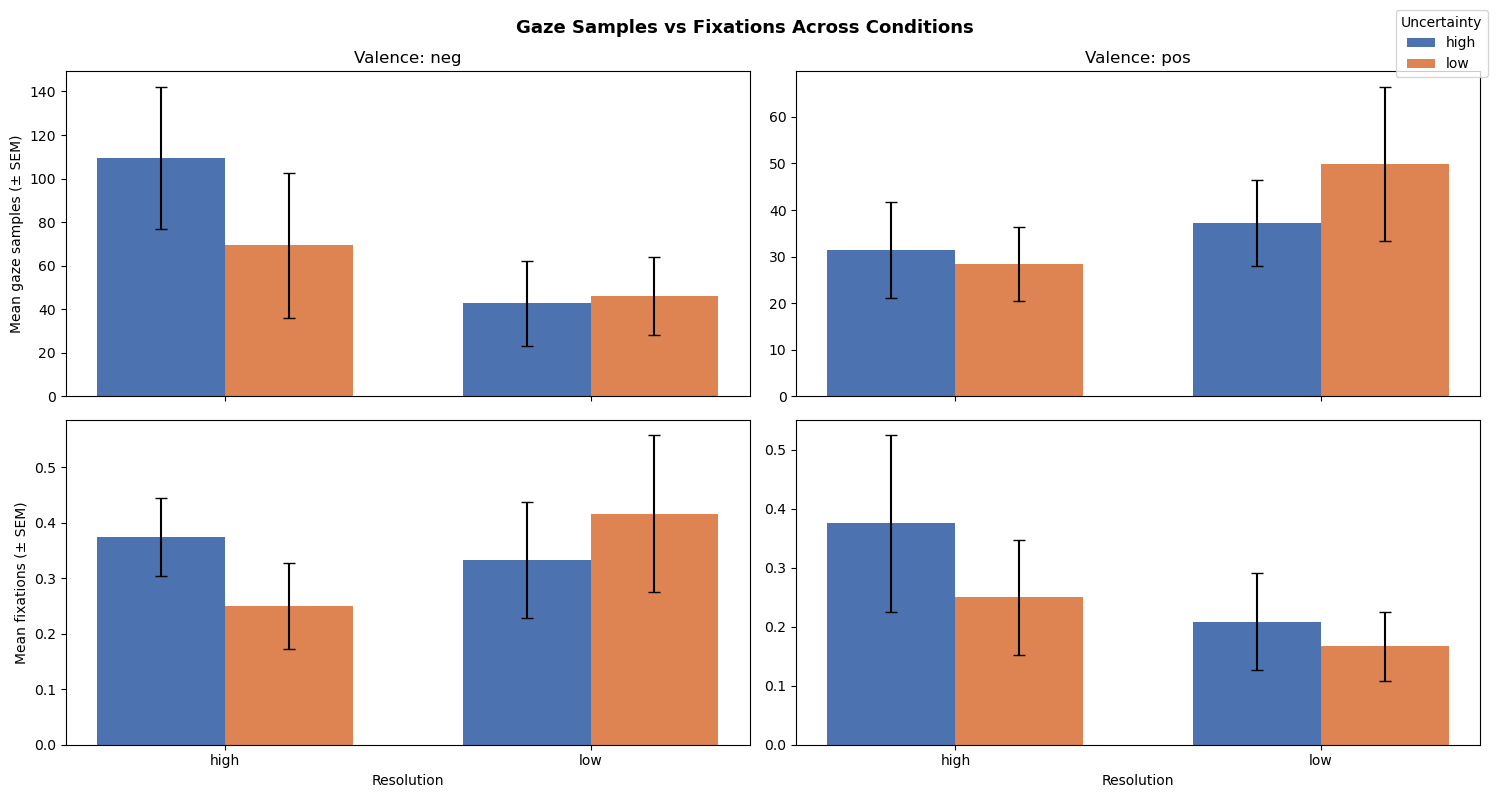

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the aggregated output already computed in the notebook
# Expected columns: real_index, mean_gaze_samples, std_gaze_samples,
# mean_fixations, std_fixations, n_participants, groupUnc, groupRes, groupVal

df = df_aggregated.copy()

required_cols = [
    "real_index",
    "mean_gaze_samples",
    "std_gaze_samples",
    "mean_fixations",
    "std_fixations",
    "n_participants",
    "groupUnc",
    "groupRes",
    "groupVal",
]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns in df_aggregated: {missing}")

# Collapse multiple sentence-level rows to one summary row per condition combination
# so the grouped bar chart can be built without duplicate resolution labels.
df = df.dropna(subset=["groupUnc", "groupRes", "groupVal"]).copy()
for col in ["groupUnc", "groupRes", "groupVal"]:
    df[col] = df[col].astype(str)

plot_df = (
    df.groupby(["groupVal", "groupUnc", "groupRes"], as_index=False)
    .agg(
        mean_gaze_samples=("mean_gaze_samples", "mean"),
        std_gaze_samples=("mean_gaze_samples", lambda s: s.std(ddof=0)),
        mean_fixations=("mean_fixations", "mean"),
        std_fixations=("mean_fixations", lambda s: s.std(ddof=0)),
        n_participants=("n_participants", "count"),
    )
    .fillna({"std_gaze_samples": 0, "std_fixations": 0})
)

# Make the later plotting helpers use the cleaned summary data.
df = plot_df.copy()

UNC_ORDER = sorted(df["groupUnc"].unique())
RES_ORDER = sorted(df["groupRes"].unique())
VAL_ORDER = sorted(df["groupVal"].unique())

BAR_WIDTH = 0.35
COLORS = {
    "high": "#4C72B0",
    "low": "#DD8452",
    "none": "#55A868",
}


def use_sem(std, n):
    """Convert std to SEM given n_participants."""
    return std / np.sqrt(n)


def plot_metric_by_condition(
    df,
    mean_col,
    std_col,
    title,
    ylabel,
    error_type="sem",
    figsize=(15, 4.5),
):
    """Grouped bar chart: x = groupRes, hue = groupUnc, one subplot per groupVal."""
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)

            means = rows[mean_col].astype(float).values
            stds = rows[std_col].astype(float).values
            n_participants = rows["n_participants"].astype(float).values
            errors = use_sem(stds, n_participants) if error_type == "sem" else stds

            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


# Primary plot: gaze samples across conditions
fig_gaze = plot_metric_by_condition(
    df,
    mean_col="mean_gaze_samples",
    std_col="std_gaze_samples",
    title="Gaze Samples Across Conditions",
    ylabel="Mean gaze samples (± SEM)",
    error_type="sem",
    figsize=(15, 5),
)
fig_gaze.savefig("gaze_samples_by_condition.png", dpi=200, bbox_inches="tight")

# Secondary plot: fixations across conditions
fig_fix = plot_metric_by_condition(
    df,
    mean_col="mean_fixations",
    std_col="std_fixations",
    title="Fixation Count Across Conditions",
    ylabel="Mean fixations (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_fix.savefig("fixations_by_condition.png", dpi=200, bbox_inches="tight")

# Combined overview for one figure
fig_combined, axes = plt.subplots(2, len(VAL_ORDER), figsize=(15, 8), sharex="col")
x = np.arange(len(RES_ORDER))

for row, (mean_col, std_col, ylabel) in enumerate(
    [
        ("mean_gaze_samples", "std_gaze_samples", "Mean gaze samples (± SEM)"),
        ("mean_fixations", "std_fixations", "Mean fixations (± SEM)"),
    ]
):
    for col, val in enumerate(VAL_ORDER):
        ax = axes[row, col]
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].astype(float).values
            stds = rows[std_col].astype(float).values
            n_participants = rows["n_participants"].astype(float).values
            errors = use_sem(stds, n_participants)
            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc if row == 0 and col == 0 else None,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_ylim(bottom=0)
        if row == 0:
            ax.set_title(f"Valence: {val}")
        if row == 1:
            ax.set_xlabel("Resolution")
        if col == 0:
            ax.set_ylabel(ylabel)

fig_combined.legend(
    *axes[0, 0].get_legend_handles_labels(),
    title="Uncertainty",
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
)
fig_combined.suptitle(
    "Gaze Samples vs Fixations Across Conditions",
    fontsize=13,
    fontweight="bold",
)
fig_combined.tight_layout()
fig_combined.savefig("combined_gaze_fixations_by_condition.png", dpi=200, bbox_inches="tight")

plt.show()

ValueError: cannot reindex on an axis with duplicate labels

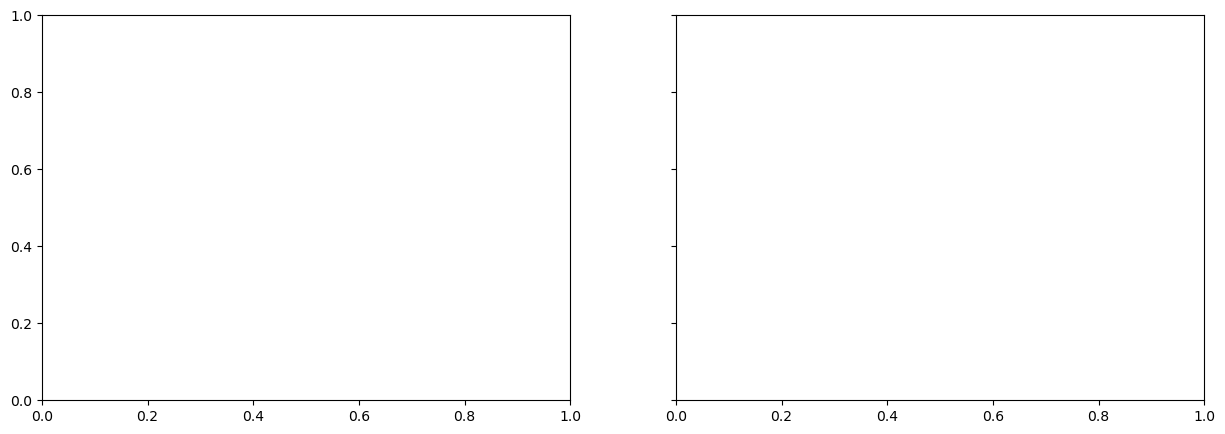

In [10]:


def plot_interaction_lines(
    df, mean_col, std_col, title, ylabel, error_type="sem", figsize=(15, 4.5)
):
    """
    Interaction line plot: x = groupRes, one line per groupUnc, one subplot per groupVal.
    Makes Uncertainty x Resolution interactions easier to spot than bars.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for unc in UNC_ORDER:
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].values
            if error_type == "sem":
                errors = use_sem(rows[std_col].values, rows["n_participants"].values)
            else:
                errors = rows[std_col].values

            ax.errorbar(
                x, means, yerr=errors, marker="o", capsize=4, linewidth=2,
                label=unc, color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


def plot_box_violin(trial_df, metric_col, title, ylabel, kind="box", figsize=(15, 4.5)):
    """
    Box or violin plot showing within-condition distribution.
    Requires TRIAL-LEVEL data (one row per trial/participant), not the
    aggregated summary dataframe — pass a separate raw dataframe here.
    trial_df must have: metric_col, groupUnc, groupRes, groupVal.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    for ax, val in zip(axes, VAL_ORDER):
        sub = trial_df[trial_df["groupVal"] == val]
        data, labels, colors = [], [], []
        for res in RES_ORDER:
            for unc in UNC_ORDER:
                vals = sub[(sub["groupRes"] == res) & (sub["groupUnc"] == unc)][metric_col].dropna()
                data.append(vals)
                labels.append(f"{res}\n{unc}")
                colors.append(COLORS.get(unc, "#999999"))

        if kind == "box":
            bp = ax.boxplot(data, labels=labels, patch_artist=True)
            for patch, c in zip(bp["boxes"], colors):
                patch.set_facecolor(c)
        else:
            parts = ax.violinplot(data, showmeans=True)
            for pc, c in zip(parts["bodies"], colors):
                pc.set_facecolor(c)
                pc.set_alpha(0.7)
            ax.set_xticks(range(1, len(labels) + 1))
            ax.set_xticklabels(labels)

        ax.set_title(f"Valence: {val}")
        ax.tick_params(axis="x", labelsize=8)

    axes[0].set_ylabel(ylabel)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


def plot_scatter_gaze_vs_fixations(df, figsize=(7, 6)):
    """
    Scatter of mean_gaze_samples vs mean_fixations, one point per condition,
    colored by Uncertainty and marker-shaped by Resolution, to check whether
    the two metrics track together or diverge across conditions.
    """
    fig, ax = plt.subplots(figsize=figsize)
    markers = {RES_ORDER[0]: "o", RES_ORDER[-1]: "s"}  # extend if >2 levels

    for unc in UNC_ORDER:
        for res in RES_ORDER:
            sub = df[(df["groupUnc"] == unc) & (df["groupRes"] == res)]
            ax.scatter(
                sub["mean_fixations"], sub["mean_gaze_samples"],
                color=COLORS.get(unc, None), marker=markers.get(res, "o"),
                s=90, edgecolor="black", linewidth=0.5,
                label=f"{unc} / {res}",
            )

    for _, row in df.iterrows():
        ax.annotate(
            row["groupVal"], (row["mean_fixations"], row["mean_gaze_samples"]),
            fontsize=7, xytext=(4, 4), textcoords="offset points",
        )

    ax.set_xlabel("Mean fixations")
    ax.set_ylabel("Mean gaze samples")
    ax.set_title("Gaze Samples vs Fixations by Condition")
    ax.legend(fontsize=8, title="Unc / Res")
    fig.tight_layout()
    return fig


def plot_heatmap(df, mean_col, title, cmap="viridis", figsize=(12, 3.5)):
    """
    Heatmap: rows = groupUnc, columns = groupRes, one tile per groupVal.
    Quick scan of which condition is highest/lowest across the full factorial.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    vmin, vmax = df[mean_col].min(), df[mean_col].max()

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]
        grid = sub.pivot(index="groupUnc", columns="groupRes", values=mean_col)
        grid = grid.reindex(index=UNC_ORDER, columns=RES_ORDER)

        im = ax.imshow(grid.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(RES_ORDER)))
        ax.set_xticklabels(RES_ORDER)
        ax.set_yticks(range(len(UNC_ORDER)))
        ax.set_yticklabels(UNC_ORDER)
        ax.set_title(f"Valence: {val}")

        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                v = grid.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                            color="white" if v > (vmin + vmax) / 2 else "black")

    fig.colorbar(im, ax=axes, shrink=0.8, label=title)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    return fig


def plot_forest(df, mean_col, std_col, title, xlabel, figsize=(8, 8)):
    """
    Forest plot: one row per condition (real_index), mean +/- 95% CI.
    Compact summary of all conditions at once.
    """
    plot_df = df.copy()
    plot_df["sem"] = use_sem(plot_df[std_col], plot_df["n_participants"])
    plot_df["ci95"] = 1.96 * plot_df["sem"]
    plot_df["label"] = (
        plot_df["groupUnc"] + " / " + plot_df["groupRes"] + " / " + plot_df["groupVal"]
    )
    plot_df = plot_df.sort_values(mean_col)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(plot_df))

    ax.errorbar(
        plot_df[mean_col], y, xerr=plot_df["ci95"],
        fmt="o", capsize=4, color="#4C72B0", ecolor="#999999",
    )
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["label"], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axvline(plot_df[mean_col].mean(), color="gray", linestyle="--", linewidth=1, alpha=0.6)
    fig.tight_layout()
    return fig


def plot_dot_with_n(df, mean_col, std_col, title, ylabel, figsize=(15, 4.5)):
    """
    Dot plot per condition (like the bar chart layout) but point SIZE encodes
    n_participants, so sample-size differences across conditions stay visible.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))
    n_min, n_max = df["n_participants"].min(), df["n_participants"].max()

    def scale_size(n):
        if n_max == n_min:
            return 200
        return 80 + 320 * (n - n_min) / (n_max - n_min)

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].values
            errors = use_sem(rows[std_col].values, rows["n_participants"].values)
            sizes = [scale_size(n) for n in rows["n_participants"].values]

            offset = (i - 0.5) * 0.15
            ax.errorbar(
                x + offset, means, yerr=errors, fmt="none",
                ecolor=COLORS.get(unc, None), capsize=3, zorder=1,
            )
            ax.scatter(
                x + offset, means, s=sizes, color=COLORS.get(unc, None),
                edgecolor="black", linewidth=0.5, label=unc, zorder=2,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(f"{title}\n(point size = n_participants)", fontsize=12, fontweight="bold")
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# 3. Primary plot: gaze samples across conditions
# ---------------------------------------------------------------------------
fig_gaze = plot_metric_by_condition(
    df,
    mean_col="mean_gaze_samples",
    std_col="std_gaze_samples",
    title="Gaze Samples Across Conditions",
    ylabel="Mean gaze samples (± SEM)",
    error_type="sem",
    figsize=(15, 5),
)
fig_gaze.savefig("gaze_samples_by_condition.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 4. Secondary plot: fixations across conditions
# ---------------------------------------------------------------------------
fig_fix = plot_metric_by_condition(
    df,
    mean_col="mean_fixations",
    std_col="std_fixations",
    title="Fixation Count Across Conditions",
    ylabel="Mean fixations (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_fix.savefig("fixations_by_condition.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 5. Optional: combined overview (gaze on top, fixations below) for one figure
# ---------------------------------------------------------------------------
fig_combined, axes = plt.subplots(2, len(VAL_ORDER), figsize=(15, 8), sharex="col")
x = np.arange(len(RES_ORDER))

for row, (mean_col, std_col, ylabel) in enumerate(
    [
        ("mean_gaze_samples", "std_gaze_samples", "Mean gaze samples (± SEM)"),
        ("mean_fixations", "std_fixations", "Mean fixations (± SEM)"),
    ]
):
    for col, val in enumerate(VAL_ORDER):
        ax = axes[row, col]
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].values
            errors = use_sem(rows[std_col].values, rows["n_participants"].values)
            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset, means, BAR_WIDTH, yerr=errors, capsize=4,
                label=unc if row == 0 and col == 0 else None,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        if row == 0:
            ax.set_title(f"Valence: {val}")
        if row == 1:
            ax.set_xlabel("Resolution")
        if col == 0:
            ax.set_ylabel(ylabel)

fig_combined.legend(
    *axes[0, 0].get_legend_handles_labels(), title="Uncertainty",
    loc="upper right", bbox_to_anchor=(1.0, 1.0)
)
fig_combined.suptitle("Gaze Samples vs Fixations Across Conditions", fontsize=13, fontweight="bold")
fig_combined.tight_layout()
fig_combined.savefig("combined_gaze_fixations_by_condition.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 6. Interaction line plots (Uncertainty x Resolution, faceted by Valence)
# ---------------------------------------------------------------------------
fig_lines_gaze = plot_interaction_lines(
    df, "mean_gaze_samples", "std_gaze_samples",
    title="Gaze Samples — Interaction of Uncertainty x Resolution",
    ylabel="Mean gaze samples (± SEM)", figsize=(15, 5),
)
fig_lines_gaze.savefig("gaze_samples_interaction_lines.png", dpi=200, bbox_inches="tight")

fig_lines_fix = plot_interaction_lines(
    df, "mean_fixations", "std_fixations",
    title="Fixations — Interaction of Uncertainty x Resolution",
    ylabel="Mean fixations (± SEM)", figsize=(15, 4),
)
fig_lines_fix.savefig("fixations_interaction_lines.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 7. Box/violin plots — REQUIRES trial-level data, not the aggregated summary.
# Uncomment and point at your raw per-trial dataframe if you have it.
# ---------------------------------------------------------------------------
# trial_df = pd.read_csv("your_trial_level_data.csv")
# fig_box_gaze = plot_box_violin(
#     trial_df, metric_col="gaze_samples", kind="box",
#     title="Gaze Samples Distribution by Condition", ylabel="Gaze samples",
# )
# fig_box_gaze.savefig("gaze_samples_boxplot.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 8. Scatter: gaze samples vs fixations, per condition
# ---------------------------------------------------------------------------
fig_scatter = plot_scatter_gaze_vs_fixations(df)
fig_scatter.savefig("gaze_vs_fixations_scatter.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 9. Heatmaps — full factorial at a glance
# ---------------------------------------------------------------------------
fig_heat_gaze = plot_heatmap(df, "mean_gaze_samples", title="Mean Gaze Samples")
fig_heat_gaze.savefig("gaze_samples_heatmap.png", dpi=200, bbox_inches="tight")

fig_heat_fix = plot_heatmap(df, "mean_fixations", title="Mean Fixations", cmap="magma")
fig_heat_fix.savefig("fixations_heatmap.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 10. Forest plots — compact all-conditions summary
# ---------------------------------------------------------------------------
fig_forest_gaze = plot_forest(
    df, "mean_gaze_samples", "std_gaze_samples",
    title="Gaze Samples by Condition (mean ± 95% CI)", xlabel="Mean gaze samples",
)
fig_forest_gaze.savefig("gaze_samples_forest.png", dpi=200, bbox_inches="tight")

fig_forest_fix = plot_forest(
    df, "mean_fixations", "std_fixations",
    title="Fixations by Condition (mean ± 95% CI)", xlabel="Mean fixations",
)
fig_forest_fix.savefig("fixations_forest.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 11. Dot plots with n_participants encoded as point size
# ---------------------------------------------------------------------------
fig_dot_gaze = plot_dot_with_n(
    df, "mean_gaze_samples", "std_gaze_samples",
    title="Gaze Samples Across Conditions", ylabel="Mean gaze samples (± SEM)",
    figsize=(15, 5),
)
fig_dot_gaze.savefig("gaze_samples_dot_with_n.png", dpi=200, bbox_inches="tight")

plt.show()